In [12]:
from ultralytics import YOLO
from PIL import Image
from torchvision import transforms
import os

import glob
import utils
from utils import boxes
from dotenv import load_dotenv
load_dotenv() 

MODEL_VPD = os.getenv('MODEL_VPD')
SAMPLE = os.getenv('SAMPLE')

In [13]:
model = YOLO(MODEL_VPD)
img = Image.open(SAMPLE)
y, x = img.size
img = transforms.Resize((1080, 1920))(img)
result = model(img)

0: 384x640 2 license_plates, 51.2ms
Speed: 5.0ms preprocess, 51.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)


In [14]:
coordinates = boxes.get_box_coordinates(result[0])

Coords: (712.0, 412.9) - (1293.5, 524.3) | Class: 0 | Confidence: 0.73
Coords: (903.7, 427.8) - (1294.1, 526.3) | Class: 0 | Confidence: 0.41


In [15]:
x1, x2, y1, y2 = boxes.get_test_box(coordinates)

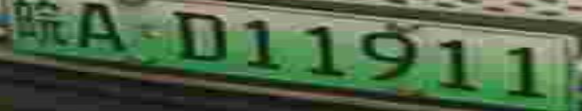

In [16]:
coords = [x1, y1, x2, y2]
boxes.cut_plate_numbers(coords, img)